# Daily Challenge: Pokemon Win Prediction Analysis

Week 9, Day 4

Goal: compute each Pokemon's win percentage from 50,000 battles, explore which stats drive winning, and train regression models to predict the win percentage.

## Setup

In [1]:
import os
import io
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

RANDOM_STATE = 42
sns.set_style('whitegrid')

## 1. Data Preparation

### Load the data

In [2]:
# Local copy in the repo; otherwise download the zip provided by the bootcamp (e.g. in Colab)
if os.path.exists("data/pokemon.csv"):
    pokemon = pd.read_csv("data/pokemon.csv")
    combats = pd.read_csv("data/combats.csv")
else:
    url = ("https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/"
           "Week%205/Day%204%20-%20Statistics%20for%20Machine%20Learning/Pokemon%20Data%20Analysis%20Tutorial.zip")
    with zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(url).read())) as z:
        pokemon = pd.read_csv(z.open("Pokemon Data Analysis Tutorial/pokemon.csv"))
        combats = pd.read_csv(z.open("Pokemon Data Analysis Tutorial/combats.csv"))

print("pokemon:", pokemon.shape, "| combats:", combats.shape)
display(pokemon.head())
display(combats.head())

pokemon: (800, 12) | combats: (50000, 3)


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


### Fix missing values

In [3]:
print(pokemon.isnull().sum())
display(pokemon[pokemon['Name'].isnull()])

#               0
Name            1
Type 1          0
Type 2        386
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
62,63,NaN,Fighting,NaN,65,105,60,60,70,95,1,False


In [4]:
# The Pokemon without a name sits between Mankey and Growlithe: it is Primeape
# (row 62 of the dataframe, Pokemon number #63)
display(pokemon.iloc[60:65])
pokemon.loc[pokemon['Name'].isnull(), 'Name'] = 'Primeape'

# Pokemon with a single type: mark Type 2 as "None"
pokemon['Type 2'] = pokemon['Type 2'].fillna('None')

print(pokemon.isnull().sum().sum(), "missing values left")
display(pokemon[pokemon['Name'] == 'Primeape'])

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
60,61,Golduck,Water,NaN,80,82,78,95,80,85,1,False
61,62,Mankey,Fighting,NaN,40,80,35,35,45,70,1,False
62,63,NaN,Fighting,NaN,65,105,60,60,70,95,1,False
63,64,Growlithe,Fire,NaN,55,70,45,70,50,60,1,False
64,65,Arcanine,Fire,NaN,90,110,80,100,80,95,1,False


0 missing values left


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
62,63,Primeape,Fighting,None,65,105,60,60,70,95,1,False


### Calculate each Pokemon's win percentage

In [5]:
# Number of battles per Pokemon (as first or second fighter) and number of wins
total_battles = pd.concat([combats['First_pokemon'], combats['Second_pokemon']]).value_counts()
wins = combats['Winner'].value_counts()

stats = pd.DataFrame({'Total_battles': total_battles, 'Wins': wins}).fillna(0)
stats['Win_percentage'] = stats['Wins'] / stats['Total_battles']

# Merge with the Pokemon characteristics
df = pokemon.merge(stats, left_on='#', right_index=True, how='left')
print(df.shape)
display(df.head())

never_fought = df['Win_percentage'].isnull()
print(f"{never_fought.sum()} Pokemon never fought -> no win percentage, removed from the analysis:")
print(df.loc[never_fought, 'Name'].tolist())
df = df[~never_fought].reset_index(drop=True)
print("Final shape:", df.shape)

(800, 15)


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Total_battles,Wins,Win_percentage
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,133.0,37.0,0.278195
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,121.0,46.0,0.380165
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,132.0,89.0,0.674242
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,125.0,70.0,0.560000
4,5,Charmander,Fire,None,39,52,43,60,50,65,1,False,112.0,55.0,0.491071


16 Pokemon never fought -> no win percentage, removed from the analysis:
['Blastoise', 'Sandshrew', 'Wigglytuff', 'Poliwag', 'Victreebel', 'Magneton', 'Ditto', 'Ariados', 'Ursaring', 'Hariyama', 'Mega Latias', 'Honchkrow', 'Servine', 'Maractus', 'Jellicent', 'Pumpkaboo Small Size']
Final shape: (784, 15)


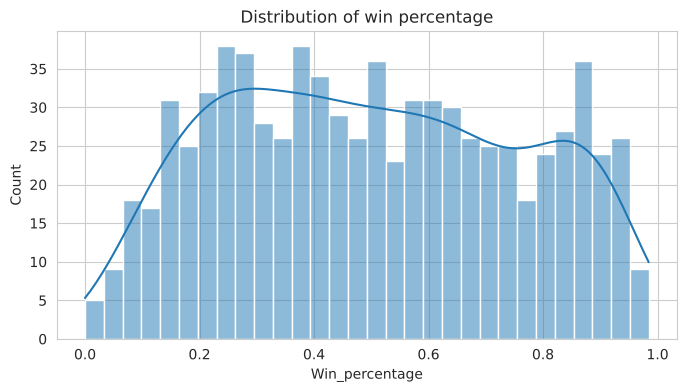

count    784.000
mean       0.501
std        0.255
min        0.000
25%        0.284
50%        0.491
75%        0.717
max        0.984
Name: Win_percentage, dtype: float64

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Win_percentage'], bins=30, kde=True)
plt.title('Distribution of win percentage')
plt.show()
display(df['Win_percentage'].describe().round(3))

## 2. Exploratory Analysis & Visualization

### Correlation matrix

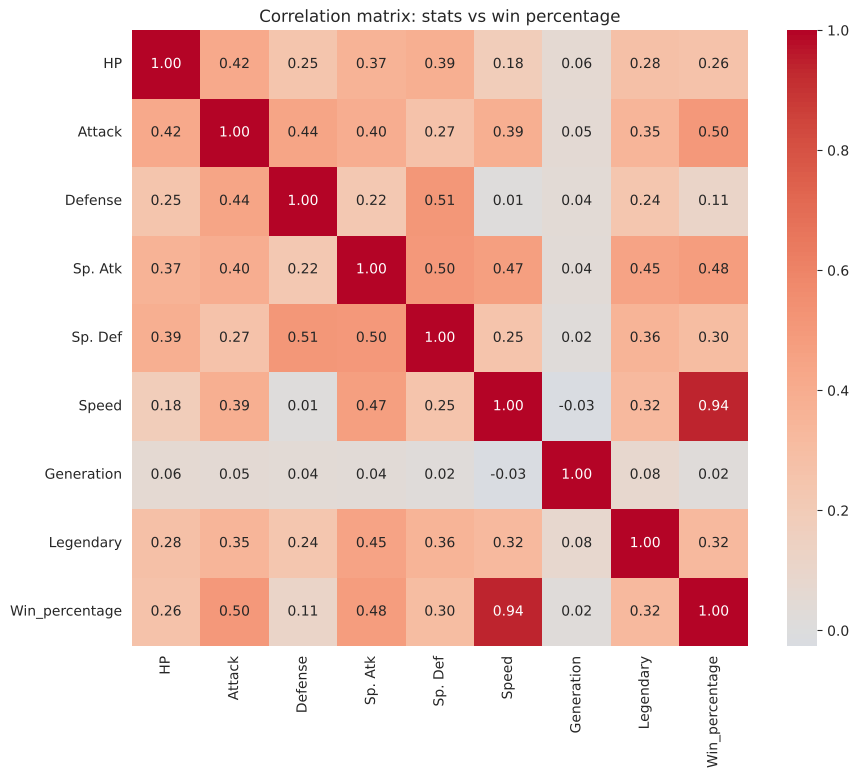

Correlation with win percentage:
Speed         0.938
Attack        0.503
Sp. Atk       0.481
Legendary     0.325
Sp. Def       0.302
HP            0.262
Defense       0.115
Generation    0.023
Name: Win_percentage, dtype: float64


In [7]:
stat_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
df['Legendary'] = df['Legendary'].astype(int)

plt.figure(figsize=(10, 8))
corr = df[stat_cols + ['Generation', 'Legendary', 'Win_percentage']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation matrix: stats vs win percentage')
plt.show()

print("Correlation with win percentage:")
print(corr['Win_percentage'].drop('Win_percentage').sort_values(ascending=False).round(3))

**Speed** is by far the stat most correlated with winning (r ≈ 0.94): in a battle, the faster Pokemon attacks first. **Attack** comes second (r ≈ 0.50), then Sp. Atk. HP, Defense and Sp. Def have weak correlations, and Generation has almost none. Legendary Pokemon win more, but mainly because they also have higher stats.

### Pairplot: stats vs win percentage

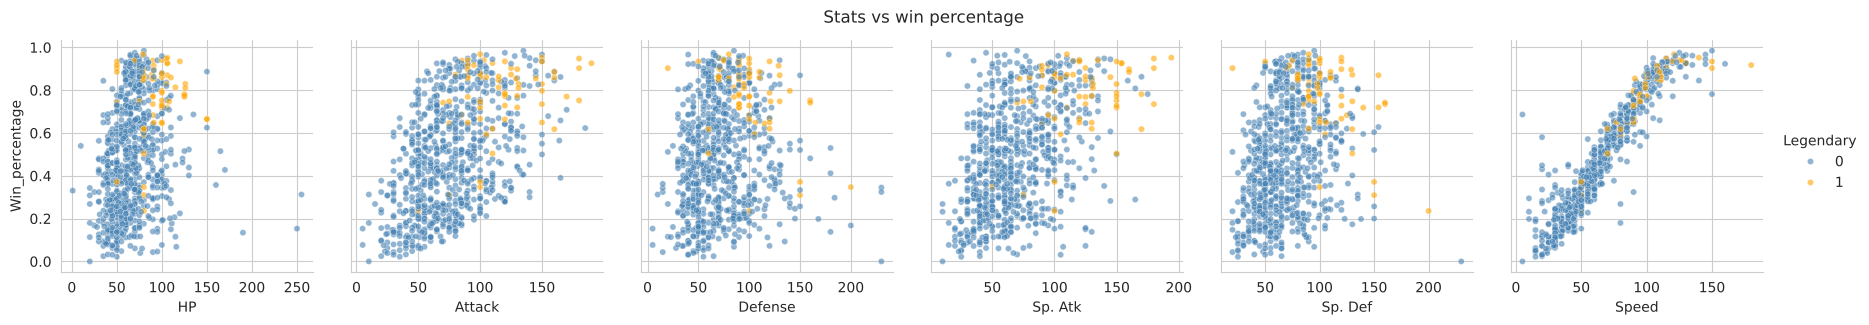

In [8]:
g = sns.PairGrid(df, x_vars=stat_cols, y_vars=['Win_percentage'], hue='Legendary', height=3, palette={0: 'steelblue', 1: 'orange'})
g.map(sns.scatterplot, alpha=0.6, s=20)
g.add_legend(title='Legendary')
plt.suptitle('Stats vs win percentage', y=1.05)
plt.show()

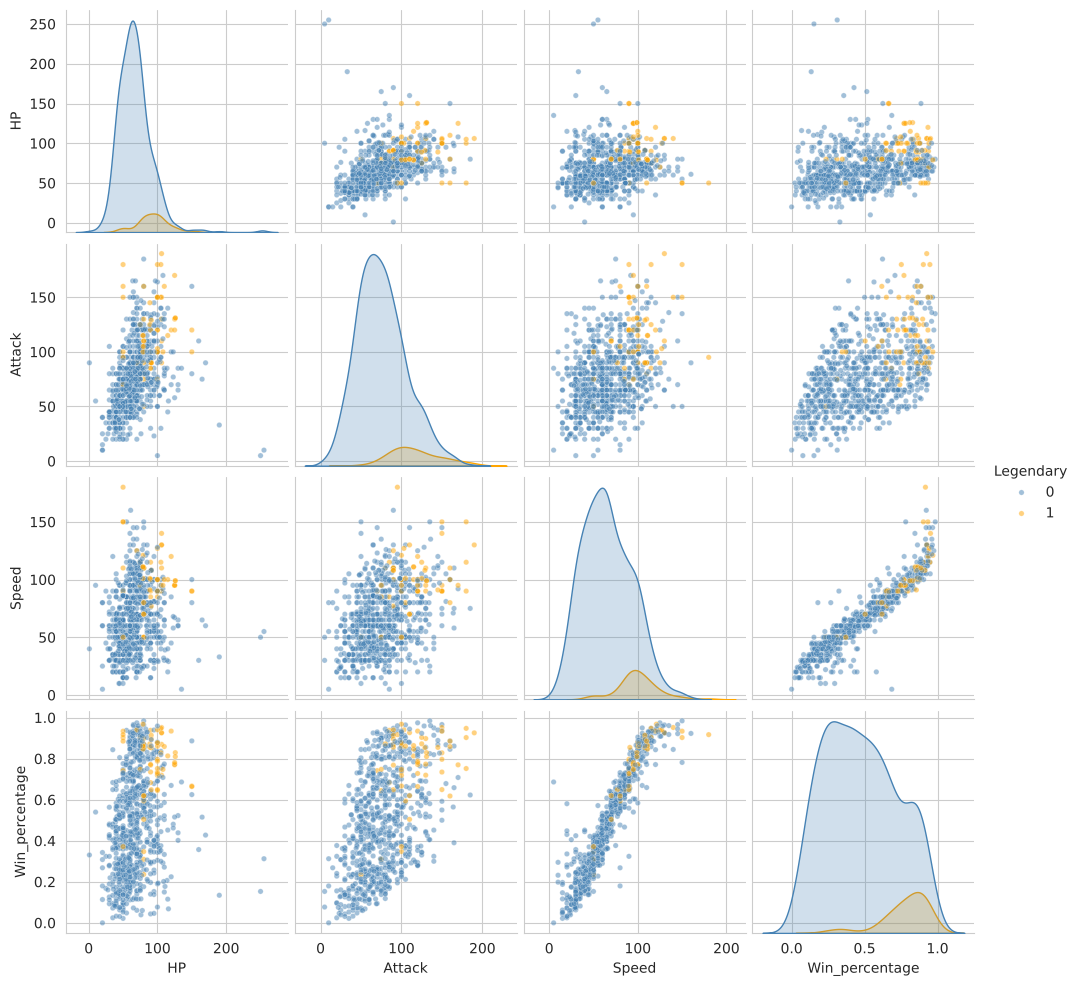

In [9]:
sns.pairplot(df[['HP', 'Attack', 'Speed', 'Win_percentage', 'Legendary']], hue='Legendary', diag_kind='kde',
             plot_kws={'alpha': 0.5, 's': 15}, palette={0: 'steelblue', 1: 'orange'})
plt.show()

### Top 10 Pokemon by win percentage

,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary,Total_battles,Win_percentage
147,Mega Aerodactyl,Rock,Flying,80,135,85,70,95,150,0,129.0,0.984496
500,Weavile,Dark,Ice,70,120,65,45,85,125,0,119.0,0.974790
688,Tornadus Therian Forme,Flying,None,79,100,80,110,90,121,1,125.0,0.968000
18,Mega Beedrill,Bug,Poison,65,150,40,15,80,145,0,119.0,0.966387
146,Aerodactyl,Rock,Flying,80,105,65,60,75,130,0,141.0,0.964539
465,Mega Lopunny,Normal,Fighting,65,136,94,54,96,135,0,129.0,0.961240
711,Greninja,Water,Dark,72,95,67,103,71,122,0,127.0,0.960630
701,Meloetta Pirouette Forme,Normal,Fighting,100,128,90,77,77,128,0,123.0,0.959350
157,Mega Mewtwo Y,Psychic,None,106,150,70,194,120,140,1,125.0,0.952000
339,Mega Sharpedo,Water,Dark,70,140,70,110,65,105,0,120.0,0.950000


,Top 10 mean,All Pokemon mean
HP,78.7,69.1
Attack,125.9,78.9
Defense,72.6,73.9
Sp. Atk,83.8,72.8
Sp. Def,85.4,72.0
Speed,130.1,68.4


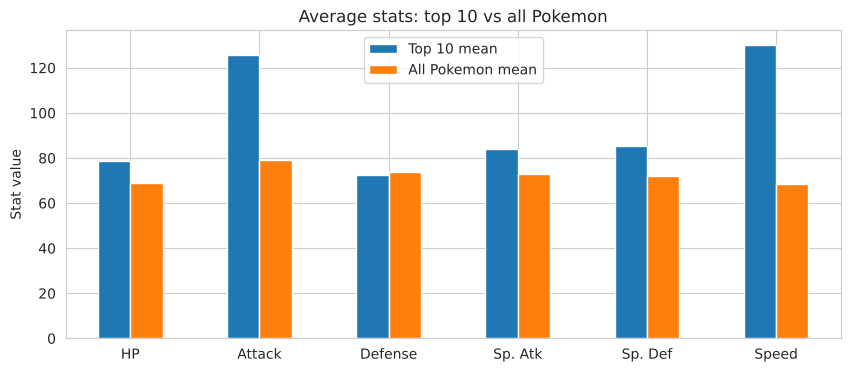

In [10]:
top10 = df.sort_values('Win_percentage', ascending=False).head(10)
display(top10[['Name', 'Type 1', 'Type 2'] + stat_cols + ['Legendary', 'Total_battles', 'Win_percentage']])

comparison = pd.DataFrame({
    'Top 10 mean': top10[stat_cols].mean(),
    'All Pokemon mean': df[stat_cols].mean(),
}).round(1)
display(comparison)

comparison.plot(kind='bar', figsize=(10, 4), rot=0)
plt.title('Average stats: top 10 vs all Pokemon')
plt.ylabel('Stat value')
plt.show()

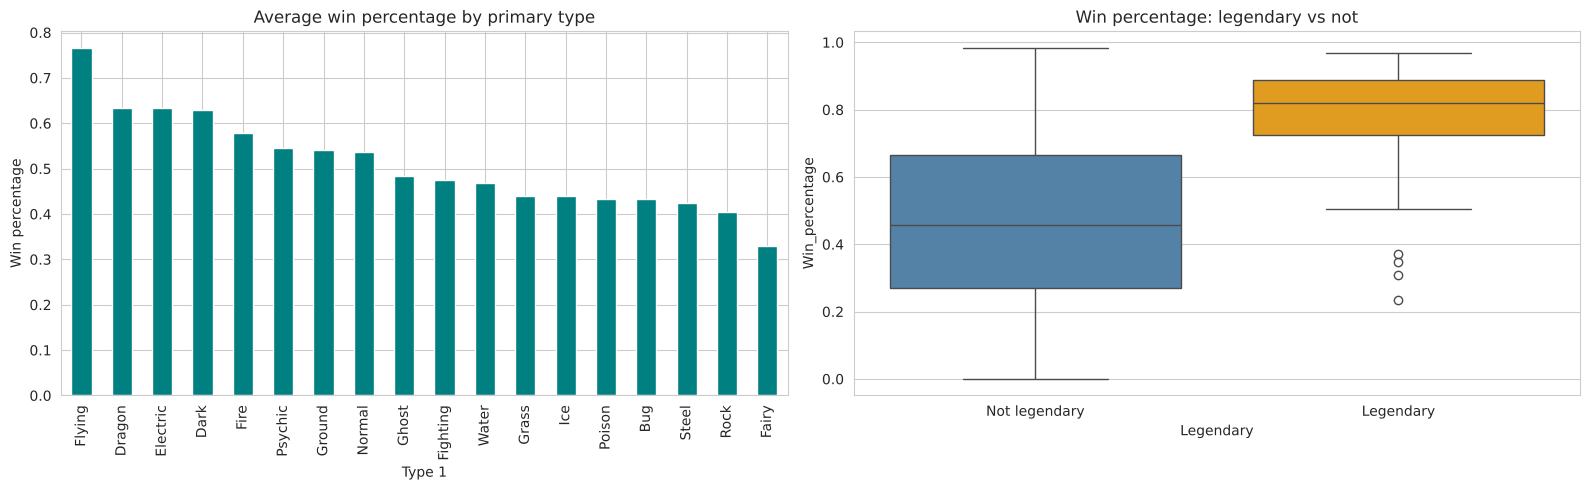

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
type_win = df.groupby('Type 1')['Win_percentage'].mean().sort_values(ascending=False)
type_win.plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Average win percentage by primary type')
axes[0].set_ylabel('Win percentage')
sns.boxplot(x='Legendary', y='Win_percentage', data=df, ax=axes[1], hue='Legendary', palette=['steelblue', 'orange'], legend=False)
axes[1].set_xticks([0, 1], ['Not legendary', 'Legendary'])
axes[1].set_title('Win percentage: legendary vs not')
plt.tight_layout()
plt.show()

**Top 10 analysis:** the best Pokemon (Mega Aerodactyl, Weavile, Tornadus Therian Forme, Mega Beedrill...) all win more than 95% of their battles. Their main advantage is **Speed**: 130 on average vs 68 for all Pokemon (almost twice as much), together with a high Attack (126 vs 79), while their Defense is just average (73 vs 74). Only 2 of the 10 are legendary: being fast matters more than being legendary. Flying, Dragon and Electric types have the highest average win rates, consistent with them being fast types.

## 3. Machine Learning

### Features and train/test split

In [12]:
# Numeric stats + legendary flag + generation + one-hot encoded types
features = pd.get_dummies(df[stat_cols + ['Generation', 'Legendary', 'Type 1', 'Type 2']],
                          columns=['Type 1', 'Type 2'], drop_first=True, dtype=int)
target = df['Win_percentage']
print("Number of features:", features.shape[1])

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Number of features: 43
Train: (627, 43) | Test: (157, 43)


### Train and evaluate the models

In [13]:
models = {
    'Linear Regression': Pipeline([('scale', StandardScaler()), ('model', LinearRegression())]),
    'SVM (SVR)': Pipeline([('scale', StandardScaler()), ('model', SVR(C=1.0, epsilon=0.01))]),
    'Decision Tree': DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    'XGBoost': XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=4, random_state=RANDOM_STATE),
}

results = {}
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred
    results[name] = {
        'MAE': mean_absolute_error(y_test, pred),
        'R²': r2_score(y_test, pred),
    }
    print(f"{name:<18} MAE = {results[name]['MAE']:.4f} | R² = {results[name]['R²']:.4f}")

results_df = pd.DataFrame(results).T.sort_values('MAE')
display(results_df.round(4))

Linear Regression  MAE = 0.0572 | R² = 0.8861
SVM (SVR)          MAE = 0.0710 | R² = 0.8334
Decision Tree      MAE = 0.0456 | R² = 0.9323


Random Forest      MAE = 0.0416 | R² = 0.9411
XGBoost            MAE = 0.0404 | R² = 0.9471


,MAE,R²
XGBoost,0.0404,0.9471
Random Forest,0.0416,0.9411
Decision Tree,0.0456,0.9323
Linear Regression,0.0572,0.8861
SVM (SVR),0.0710,0.8334


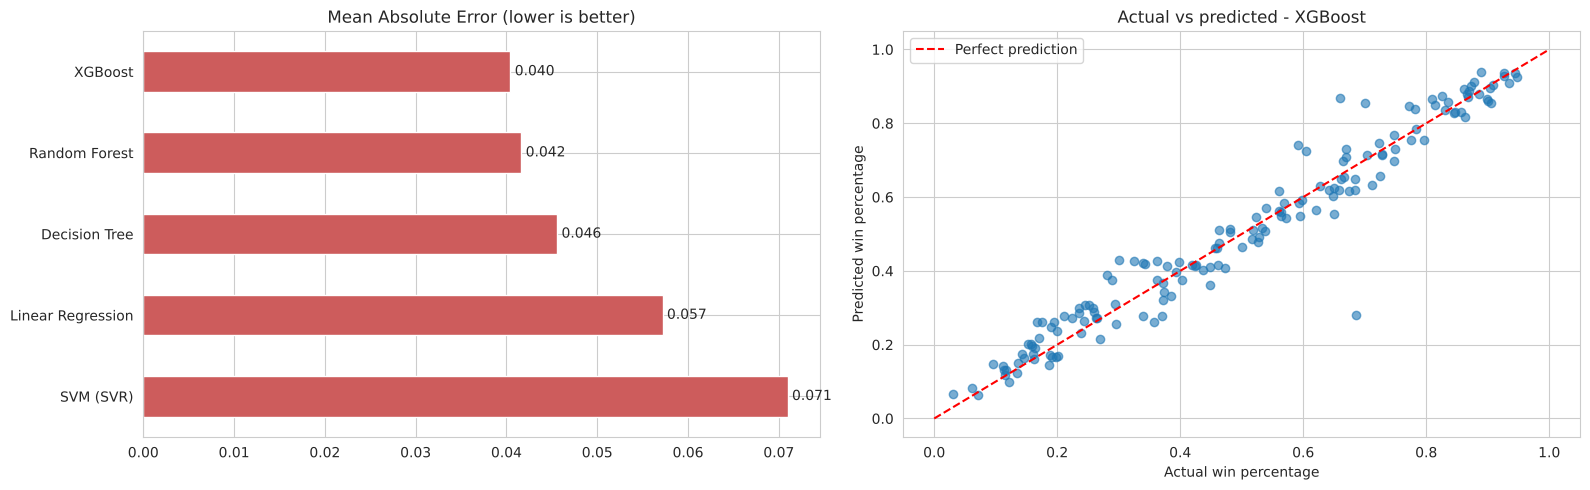

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
results_df['MAE'].plot(kind='barh', ax=axes[0], color='indianred')
axes[0].invert_yaxis()
axes[0].set_title('Mean Absolute Error (lower is better)')
for i, v in enumerate(results_df['MAE']):
    axes[0].text(v, i, f' {v:.3f}', va='center')

best_name = results_df.index[0]
axes[1].scatter(y_test, predictions[best_name], alpha=0.6)
axes[1].plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
axes[1].set_xlabel('Actual win percentage')
axes[1].set_ylabel('Predicted win percentage')
axes[1].set_title(f'Actual vs predicted - {best_name}')
axes[1].legend()
plt.tight_layout()
plt.show()

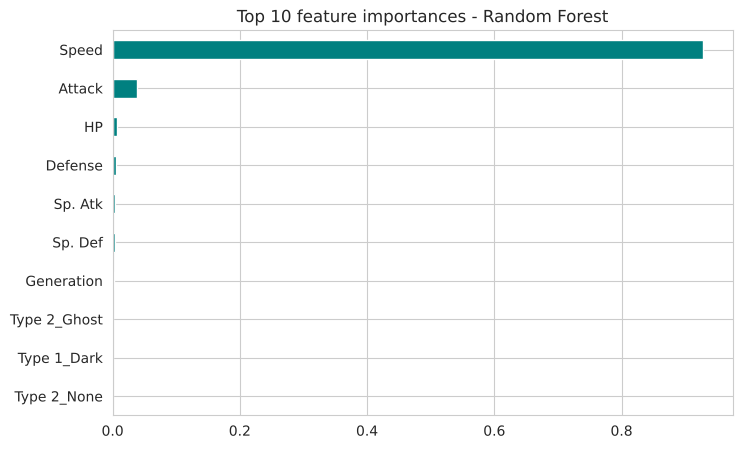

In [15]:
# Which features does the tree-based model rely on?
rf = models['Random Forest']
importances = pd.Series(rf.feature_importances_, index=features.columns).sort_values(ascending=False).head(10)
importances.sort_values().plot(kind='barh', figsize=(8, 5), color='teal')
plt.title('Top 10 feature importances - Random Forest')
plt.show()

In [16]:
# 5-fold cross-validation on the full dataset to confirm the ranking is stable
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_mae = {name: -cross_val_score(model, features, target, cv=cv, scoring='neg_mean_absolute_error').mean()
          for name, model in models.items()}
display(pd.Series(cv_mae, name='CV MAE').sort_values().round(4).to_frame())

,CV MAE
XGBoost,0.0383
Random Forest,0.0415
Decision Tree,0.0477
Linear Regression,0.0564
SVM (SVR),0.0658


### Dimensionality reduction with PCA

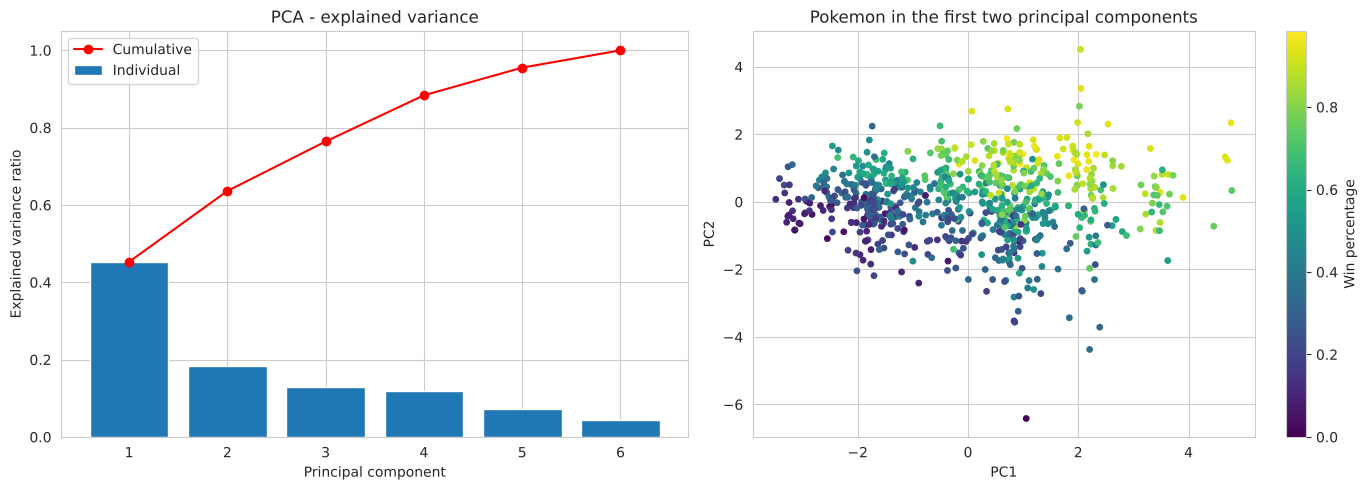

,PC1,PC2
HP,0.393,-0.084
Attack,0.440,0.016
Defense,0.363,-0.628
Sp. Atk,0.456,0.306
Sp. Def,0.447,-0.243
Speed,0.335,0.668


In [17]:
# PCA on the 6 scaled stats
scaled_stats = StandardScaler().fit_transform(df[stat_cols])
pca = PCA().fit(scaled_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, 7), pca.explained_variance_ratio_, label='Individual')
axes[0].plot(range(1, 7), np.cumsum(pca.explained_variance_ratio_), 'ro-', label='Cumulative')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('PCA - explained variance')
axes[0].legend()

pcs = pca.transform(scaled_stats)
sc = axes[1].scatter(pcs[:, 0], pcs[:, 1], c=df['Win_percentage'], cmap='viridis', s=15)
plt.colorbar(sc, ax=axes[1], label='Win percentage')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Pokemon in the first two principal components')
plt.tight_layout()
plt.show()

display(pd.DataFrame(pca.components_[:2].T, index=stat_cols, columns=['PC1', 'PC2']).round(3))

In [18]:
# Does a model trained on principal components do as well?
for n in [2, 4, 6]:
    pca_model = Pipeline([('scale', StandardScaler()), ('pca', PCA(n_components=n)),
                          ('model', RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE))])
    pca_model.fit(X_train[stat_cols], y_train)
    mae = mean_absolute_error(y_test, pca_model.predict(X_test[stat_cols]))
    print(f"Random Forest on {n} principal components: MAE = {mae:.4f}")

Random Forest on 2 principal components: MAE = 0.1089


Random Forest on 4 principal components: MAE = 0.0871


Random Forest on 6 principal components: MAE = 0.0728


PC1 is a general "overall strength" axis (all stats load positively), and PC2 mostly opposes **Speed** (+0.67) to **Defense** (−0.63). The first two components explain only part of the variance, and the models trained on principal components are clearly worse (MAE ≈ 0.11 with 2 components, ≈ 0.07 even with all 6) than the models trained on the original features (≈ 0.04). Win percentage depends mainly on *one* original stat, Speed: PCA mixes it with the other stats, so a tree can no longer split directly on it. PCA is useful here for visualisation, not for improving the model.

## Conclusion

- **Data preparation:** the missing name (row 62, Pokemon #63) was filled with *Primeape*, single-type Pokemon got `Type 2 = "None"`, and the win percentage was computed from the 50,000 battles. 16 Pokemon never fought and were removed.
- **EDA:** **Speed** explains most of the win percentage (r ≈ 0.94), followed by Attack. The top 10 Pokemon are almost all very fast Mega evolutions, not necessarily legendary ones.
- **Machine learning:** tree-based models give the lowest error: **XGBoost MAE = 0.040** (R² = 0.95), then Random Forest (MAE = 0.042) and Decision Tree (0.046), i.e. an average error of about 4 percentage points on the win percentage. Linear Regression (0.057) and SVR (0.071) are behind. Linear Regression is already decent (R² ≈ 0.89) because the relationship with Speed is almost linear, but it cannot capture non-linear effects (e.g. the win rate saturates near 100% once a Pokemon is faster than almost every opponent). The 5-fold cross-validation gives the same ranking (XGBoost CV MAE ≈ 0.038).
- **Best model: XGBoost**, closely followed by Random Forest, with Speed as the dominant feature by far.